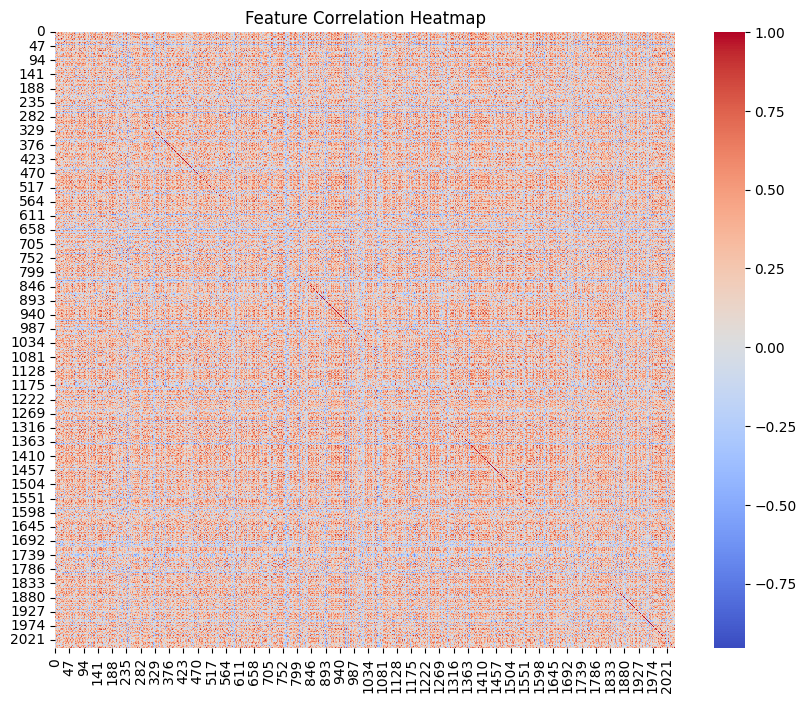


Original Results: {'SVM': 0.25, 'RF': 0.625, 'MLP': 0.75}

PCA 99% Components: 15
Results: {'SVM': 0.5, 'RF': 0.5, 'MLP': 0.5}

PCA 95% Components: 13
Results: {'SVM': 0.5, 'RF': 0.625, 'MLP': 0.625}


ValueError: n_splits=5 cannot be greater than the number of members in each class.

In [2]:
# =========================================
# LAB 10 – FEATURE ANALYSIS + PCA + SHAP + LIME
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score

from lime.lime_tabular import LimeTabularExplainer
import shap


# =========================================
# LOAD DATA
# =========================================

def load_data():
    X = np.load("X_resnet.npy")
    y = np.load("y_resnet.npy")
    return train_test_split(X, y, test_size=0.3, random_state=42)


# =========================================
# A1 – CORRELATION HEATMAP
# =========================================

def plot_correlation(X):

    df = pd.DataFrame(X)

    corr = df.corr()

    plt.figure(figsize=(10,8))
    sns.heatmap(corr, cmap="coolwarm")
    plt.title("Feature Correlation Heatmap")
    plt.show()


# =========================================
# PCA FUNCTION
# =========================================

def apply_pca(X_train, X_test, variance):

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA()
    pca.fit(X_train_scaled)

    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    n_components = np.argmax(cumulative_variance >= variance) + 1

    pca = PCA(n_components=n_components)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    return X_train_pca, X_test_pca, n_components


# =========================================
# MODEL EVALUATION
# =========================================

def evaluate_models(X_train, X_test, y_train, y_test):

    models = {
        "SVM": SVC(),
        "RF": RandomForestClassifier(),
        "MLP": MLPClassifier(max_iter=500)
    }

    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        results[name] = accuracy_score(y_test, y_pred)

    return results


# =========================================
# A4 – SEQUENTIAL FEATURE SELECTION
# =========================================

def sequential_selection(X_train, y_train):

    model = RandomForestClassifier()

    sfs = SequentialFeatureSelector(
        model,
        n_features_to_select=20,
        direction="forward"
    )

    X_selected = sfs.fit_transform(X_train, y_train)

    return X_selected


# =========================================
# A5 – LIME
# =========================================

def lime_explanation(model, X_train, X_test):

    explainer = LimeTabularExplainer(
        training_data=X_train,
        mode="classification"
    )

    exp = explainer.explain_instance(
        X_test[0],
        model.predict_proba
    )

    return exp


# =========================================
# A5 – SHAP
# =========================================

def shap_explanation(model, X_train):

    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_train[:10])

    shap.summary_plot(shap_values, X_train[:10])


# =========================================
# MAIN
# =========================================

if __name__ == "__main__":

    X_train, X_test, y_train, y_test = load_data()

    # A1
    plot_correlation(X_train)

    # ORIGINAL
    original_results = evaluate_models(X_train, X_test, y_train, y_test)
    print("\nOriginal Results:", original_results)

    # A2 – PCA 99%
    X_train_99, X_test_99, comp_99 = apply_pca(X_train, X_test, 0.99)
    results_99 = evaluate_models(X_train_99, X_test_99, y_train, y_test)

    print("\nPCA 99% Components:", comp_99)
    print("Results:", results_99)

    # A3 – PCA 95%
    X_train_95, X_test_95, comp_95 = apply_pca(X_train, X_test, 0.95)
    results_95 = evaluate_models(X_train_95, X_test_95, y_train, y_test)

    print("\nPCA 95% Components:", comp_95)
    print("Results:", results_95)

    # A4 – Sequential Feature Selection
    X_train_sfs = sequential_selection(X_train, y_train)
    X_test_sfs = X_test[:, :X_train_sfs.shape[1]]

    results_sfs = evaluate_models(X_train_sfs, X_test_sfs, y_train, y_test)
    print("\nSFS Results:", results_sfs)

    # A5 – LIME
    model = RandomForestClassifier()
    model.fit(X_train, y_train)

    lime_exp = lime_explanation(model, X_train, X_test)
    print("\nLIME:", lime_exp.as_list())

    # SHAP
    shap_explanation(model, X_train)